Примечание:
* GPU
 * Для ускорения обучения теперь можно использовать видеокарту (включите её в Edit/Notebook settings/Hardware accelerator -> GPU
 * После включения сеть можно переводить на видеокарту с помощью .to(device), так же нужно переводить в память видеокарты входные тензоры и лосс-функцию.

* Поскольку теперь результаты зависят от ещё большего числа параметров, давайте зафиксируем некоторые из них, поскольку нас интересуют не они:
 * Пусть оптимайзер будет `SGD` с `lr = 0.01`
 * Пусть `batch_size = 256`
 * Для CIFAR10 параметры нормализации: 
  ```python
  torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],[0.2470, 0.2434, 0.2615])
  ```
* Используйте трюк с `dummy_input` в init:
```python
dummy_imput = torch.rand(1, 3, 32, 32)
out = self.conv(dummy_imput)
print('Conv out:', out.shape[1])
self.fc = nn.Linear(out.shape[1], 10)
```

# Задание 1. Функция свертки

Реализуйте функцию свёртки `conv(x, kernel, stride, pad)`, где:


* $\text{x}$: Двумерный массив размером $(W,H)$;
* $\text{kernel}$: ядро свёртки размером $(K, K)$;
* $\text{stride}$: шаг ядра свёртки. $0 < \text{stride} \leq \min(W,H)$;
* $\text{pad}$: ширина дополнения с каждой из сторон массива. $\text{pad} \geq 0$.

Результатом работы функции является следующее значения:
* $out$: Результат свертки входных данных $\text{x}$, имеющий размер $(H', W')$: 
  - $H' = 1 + (H + 2 \cdot pad - K)\ //\  stride$;
  - $W' = 1 + (W + 2 \cdot pad - K)\  //\ stride$.

In [19]:
import numpy as np
a=np.arange(9).reshape((3,3))
M = np.block([[a,a],[a,a]])

a = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
# a = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

def conv(x, kernel, stride, pad):
  H, W = x.shape
  K, K = kernel.shape
  H1 = 1 + (H + 2*pad - K)//stride
  W1 = 1 + (W + 2*pad - K)//stride
  out = np.zeros((H1, W1))
  for i in range(H1):
    for j in range(W1):
      for p in range(K):
        for q in range(K):
          if i*stride + p - pad < H and j*stride + q - pad < W and i*stride + p - pad >= 0 and j*stride + q - pad >= 0:
            out[i][j] += x[i*stride + p - pad][j*stride + q - pad]*kernel[p][q]
  return out

conv(M, a, 1, 1)
# conv(M, k, 2, 1)

array([[0., 1., 2., 0., 1., 2.],
       [3., 4., 5., 3., 4., 5.],
       [6., 7., 8., 6., 7., 8.],
       [0., 1., 2., 0., 1., 2.],
       [3., 4., 5., 3., 4., 5.],
       [6., 7., 8., 6., 7., 8.]])

Воспользуйтесь созданной функцией `conv` для применения [оператора Собеля](https://ru.wikipedia.org/wiki/%D0%9E%D0%BF%D0%B5%D1%80%D0%B0%D1%82%D0%BE%D1%80_%D0%A1%D0%BE%D0%B1%D0%B5%D0%BB%D1%8F) к изображению.  
Выведите на экран изначальное изображение, приближённые производные по вертикали, горизонтали, и норму градиента (корень от суммы квадратов производных).

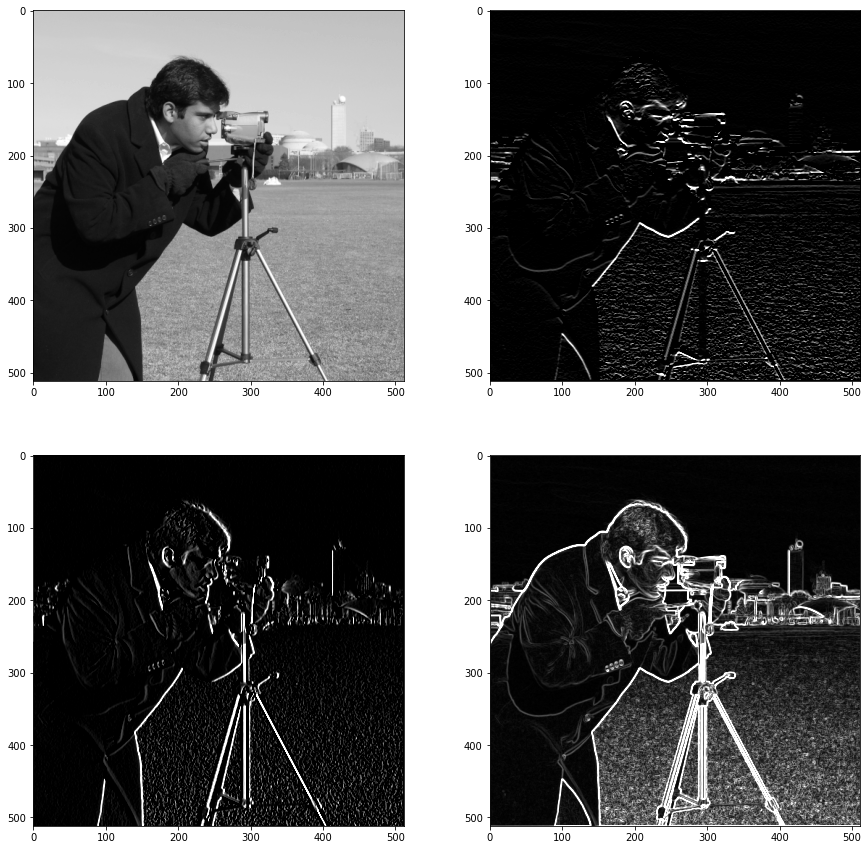

In [20]:
import matplotlib.pyplot as plt
from skimage import data

camera = data.camera()
fig, axs = plt.subplots(2, 2, figsize=(15,15))
axs[0, 0].imshow(camera, cmap='gray', vmin=0, vmax=255)

G_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
G_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
G = np.sqrt(G_x**2 + G_y**2)

out_x = conv(camera, G_x, 1, 1)
out_y = conv(camera, G_y, 1, 1)
out = np.sqrt(out_x**2 + out_y**2)
axs[0, 1].imshow(out_x, cmap='gray', vmin=0, vmax=255)
axs[1, 0].imshow(out_y, cmap='gray', vmin=0, vmax=255)
axs[1, 1].imshow(out, cmap='gray', vmin=0, vmax=255)

# Задание 2. Создание сверточной сети для CIFAR10

Создайте сверточную сеть на Pytorch и обучите ее на СIFAR10.  
* Используйте не более трёх [сверточных](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) и не более двух [полносвязанных](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) слоев, а также один слой [пулинга](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) между ними (слой пулинга и аргумент stride у сверточных слоев помогут избежать большой размерности на входе в линейный слой). 
* Функцию активации выберите на свое усмотрение.  
* Не применяйте слои других типов.  
* Используйте код для обучения из лекции №5.

In [21]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class TwoLayerCNN(nn.Module):
    def __init__(self):
        super(TwoLayerCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,10,kernel_size=(3,3),padding=1,padding_mode='replicate'), 
            nn.ReLU(),  # 32x32
            nn.Conv2d(10,16,kernel_size=(4,4),padding=1,padding_mode='replicate'), 
            nn.ReLU(),  # 31x31
            nn.Conv2d(16,32,kernel_size=(4,4),padding=1,dilation=2,padding_mode='replicate'), 
            nn.ReLU(),  # 28x28
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(), 
            nn.Linear(5408,200), 
            nn.ReLU(),
            nn.Linear(200,10),
            nn.ReLU()
            )
    def forward(self, x): 
        x = self.conv(x) 
        return x

        

Метод для подсчета точности

In [22]:
# Validation function. Don't change this code

def validate(model, test_loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

Загрузите CIFAR10

In [23]:
import torchvision
from torchvision.datasets import CIFAR10

transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],[0.2470, 0.2434, 0.2615])]) 

trainset = CIFAR10(root='./CIFAR10', train=True, download=True, transform=transform)
testset = CIFAR10(root='./CIFAR10', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


Разместите код для обучения в этом блоке. 

In [24]:
import torch
from torch.utils.data import DataLoader
batch_size = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
classnames = ['Самолет', 'Автомобиль', 'Птица', 'Кошка', 'Олень', 'Собака', 'Лягушка', 'Лошадь', 'Корабль', 'Грузовик']
loss_hist = [] 
accuracy_test = []

def train2(model, criterion, optimizer, num_epochs = 10, tag = "cifar10"):
  for epoch in range(0, num_epochs, 1):
    ep_loss = 0
    print(epoch, end = ' ')
    for _, batch in enumerate(train_loader, 0):
      imgs, labels = batch
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      loss = criterion(outputs, labels)
      loss.backward()
      ep_loss += loss.item()
      optimizer.step()
      optimizer.zero_grad()
      
    loss_hist.append(ep_loss /len(train_loader))
    accuracy = validate(model, test_loader)
    accuracy_test.append(accuracy)
    print(f"Epoch={epoch} loss={loss_hist[epoch]} accuracy={accuracy:.4f}")
  # return accuracy

model = TwoLayerCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) 
criterion = nn.CrossEntropyLoss().to(device)
train2(model,criterion, optimizer, num_epochs = 1)


Using device: cuda
0 Epoch=0 loss=2.301384048802512 accuracy=0.1260


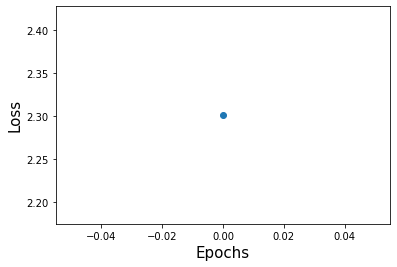

In [25]:
num_epochs = 1
plt.plot(range(num_epochs), loss_hist)
plt.scatter(range(num_epochs), loss_hist)

plt.xlabel("Epochs",fontsize=15)
plt.ylabel("Loss",fontsize=15)
plt.show()

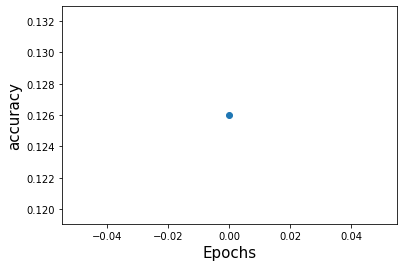

In [26]:
plt.plot(range(num_epochs),accuracy_test)
plt.scatter(range(num_epochs), accuracy_test)

plt.xlabel("Epochs",fontsize=15)
plt.ylabel("accuracy",fontsize=15)
plt.show()


# Задание 3. Accuracy от числа свёрточных слоёв

Постройте график зависимости точности вашей модели от количества свёрточных слоёв в ней. График строится на основе точности модели после десятой эпохи обучения. 

In [27]:
def train3(model, criterion, optimizer, num_epochs = 10, tag = "cifar10"):
  for epoch in range(0, num_epochs, 1):
    # ep_loss = 0
    for _, batch in enumerate(train_loader, 0):
      imgs, labels = batch
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      loss = criterion(outputs, labels)
      loss.backward()
      # ep_loss += loss.item()
      optimizer.step()
      optimizer.zero_grad()
    accuracy = validate(model, test_loader)
    return accuracy

class CNN_0(nn.Module):
    def __init__(self):
        super().__init__() 
        self.fc1 = nn.Linear(32*32*3, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

class CNN_1(nn.Module):
    def __init__(self):
        super().__init__() 
        self.fc1 = nn.Conv2d(3, 32, 16)
        self.fc2 = nn.Linear(32*17*17, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        #print(x.size())
        x = x.view(-1, 32*17*17)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

class CNN_2(nn.Module):
    def __init__(self):
        super().__init__() 
        self.fc1 = nn.Conv2d(3, 32, 16)
        self.fc2 = nn.Conv2d(32, 16, 8)
        self.fc3 = nn.Linear(16*10*10, 64)
        self.fc4 = nn.Linear(64, 10)
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        #print(x.size())
        x = x.view(-1, 16*10*10)
        x = self.fc3(x)
        x = F.relu(x)
        x = self.fc4(x)
        return x

class CNN_3(nn.Module):
    def __init__(self):
        super().__init__() 
        self.fc1 = nn.Conv2d(3, 32, 16)
        self.fc2 = nn.Conv2d(32, 16, 8)
        self.fc3 = nn.MaxPool2d(8)
        self.fc4 = nn.Linear(16, 64)
        self.fc5 = nn.Linear(64, 10)
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.relu(x)
        #print(x.size())
        x = x.view(-1, 16)
        x = self.fc4(x)
        x = F.relu(x)
        x = self.fc5(x)
        return x

model = CNN_0().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss().to(device)
train3(model, criterion, optimizer, num_epochs = 1)

0.3726

In [28]:
import matplotlib.pyplot as plt

model_0 = CNN_0()
model_1 = CNN_1()
model_2 = CNN_2()
model_3 = CNN_3()

acc0 = train3(model, criterion, optimizer, num_epochs = 10)
acc1 = train3(model, criterion, optimizer, num_epochs = 10)
acc2 = train3(model, criterion, optimizer, num_epochs = 10)
acc3 = train3(model, criterion, optimizer, num_epochs = 10)

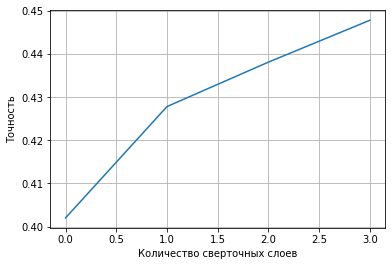

In [29]:
plt.plot([acc0, acc1, acc2, acc3])
plt.grid(True)
plt.xlabel('Количество сверточных слоев')
plt.ylabel('Точность')
plt.show()

Вывод:  
Чем больше сверточных слоев - тем выше точность. Но, вероятно влияет не только количество, но и размерность слоев.

# Задание 4. Сверточная сеть для датасетов не из torch

Дан датасет для классификации заболеваний растений. Три zip архива внутри каждого находится основная папка, и три подпапки на каждый класс.

* Изображения растений (500, 500, 3) (uint8)
* Три папки-класса: `angular_leaf_spot`, `bean_rust`, `healthy`

Используя созданные датасеты, обучите свёрточную нейронную сеть для определения заболевания растения. Используя фиксированную (по свёрточным слоям) архитектуру модели, посмотрите на качество обучения при различных размерах входных изображений `side_size` и опишите причину наблюдаемой закономерности.

In [30]:
!wget https://storage.googleapis.com/ibeans/train.zip
!wget https://storage.googleapis.com/ibeans/validation.zip
!wget https://storage.googleapis.com/ibeans/test.zip

--2022-04-21 17:51:49--  https://storage.googleapis.com/ibeans/train.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.69.128, 64.233.183.128, 173.194.193.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.69.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143812152 (137M) [application/zip]
Saving to: ‘train.zip.1’

train.zip.1         100%[===================>] 137.15M   199MB/s    in 0.7s    

2022-04-21 17:51:50 (199 MB/s) - ‘train.zip.1’ saved [143812152/143812152]

--2022-04-21 17:51:50--  https://storage.googleapis.com/ibeans/validation.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.74.128, 209.85.145.128, 209.85.147.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.74.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18504213 (18M) [application/zip]
Saving to: ‘validation.zip.1’

validation.zip.1    100%[===============

In [31]:
!unzip train.zip
!unzip validation.zip
!unzip test.zip

Archive:  train.zip
replace train/healthy/healthy_train.265.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Archive:  validation.zip
replace validation/healthy/healthy_val.6.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Archive:  test.zip
replace test/healthy/healthy_test.21.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [32]:
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Compose, ToPILImage
from torchvision.transforms import Normalize, Resize

from glob import glob
import torch
import os

In [33]:
class BeanDataset(Dataset):
    def __init__(self, img_dir, side_size = 500):
        # folder with images
        self.img_dir = img_dir
        # ordered list of all the images
        self.files = sorted(glob(f'{img_dir}/*/*.jpg'))
        class_names = sorted(os.listdir(img_dir))
        # map names to class idx
        self.class_dir = {name:idx for idx, name in enumerate(class_names)}

        # set of transforms applied to the images
        self.transforms = Compose([ToPILImage(),
                                  Resize(side_size),
                                  ToTensor(),
                                  Normalize(
                                      mean = [0.5183, 0.4845, 0.6570],
                                      std = [0.2111, 0.2227, 0.2291]
                                  )])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        image = read_image(file_path).type(torch.DoubleTensor)

        # applying transforms
        transformed_img = self.transforms(image)
        
        # picking the penultimate folder name
        label_name = file_path.split('/')[-2]
        label = self.class_dir[label_name]
        
        return transformed_img, label

In [34]:
train_dataset = BeanDataset('./train/')
valid_dataset = BeanDataset('./validation/')
test_dataset = BeanDataset('./test/')

In [35]:
train_loader = DataLoader(train_dataset, batch_size = 50)
test_loader = DataLoader(test_dataset, batch_size = 50)

In [124]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train5(model, criterion, optimizer, num_epochs = 10):
  for epoch in range(num_epochs):
    print(epoch, end = ' ')
    for _, batch in enumerate(train_loader, 0):
          imgs, labels = batch
          imgs, labels = imgs.to(device), labels.to(device)
          outputs = model(imgs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()
    print(validate(model, train_loader), end = '\n')
  accuracy = validate(model, test_loader)
  print(accuracy)
  return accuracy

class CNN_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc0 = nn.MaxPool2d(5, 5) 
        self.fc1 = nn.Conv2d(3, 32, 8, stride = 4)
        self.fc2 = nn.Conv2d(32, 8, 8, stride = 1)
        self.fc3 = nn.MaxPool2d(8, 1)
        self.fc4 = nn.Linear(96800, 3)
    def forward(self, x):
        x = self.fc0(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.relu(x)
        x = x.view(-1, 96800)
        x = self.fc4(x)
        return x



In [86]:
model = CNN_3().to(device) 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  
criterion = nn.CrossEntropyLoss().to(device)
acc_100 = train5(model, criterion, optimizer, num_epochs = 20)

0 0.32978723404255317
1 0.32978723404255317
2 0.33365570599613154
3 0.3481624758220503
4 0.32978723404255317
5 0.33268858800773693
6 0.3404255319148936
7 0.3965183752417795
8 0.3404255319148936
9 0.3694390715667311
10 0.40135396518375244
11 0.34235976789168276
12 0.3781431334622824
13 0.3597678916827853
14 0.36847195357833656
15 0.3733075435203095
16 0.38878143133462284
17 0.3994197292069632
18 0.40425531914893614
19 0.4206963249516441
0.4296875


In [90]:
model = CNN_3().to(device) 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  
criterion = nn.CrossEntropyLoss().to(device)
acc_250 = train5(model, criterion, optimizer, num_epochs = 20)

0 0.32978723404255317
1 0.32978723404255317
2 0.32978723404255317
3 0.32978723404255317
4 0.32978723404255317
5 0.32978723404255317
6 0.32978723404255317
7 0.3307543520309478
8 0.32978723404255317
9 0.32978723404255317
10 0.32978723404255317
11 0.32978723404255317
12 0.34235976789168276
13 0.3317214700193424
14 0.33849129593810445
15 0.3491295938104449
16 0.3539651837524178
17 0.35589941972920697
18 0.35589941972920697
19 0.3520309477756286
0.3671875


In [121]:
model = CNN_3().to(device) 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  
criterion = nn.CrossEntropyLoss().to(device)
acc_160 = train5(model, criterion, optimizer, num_epochs = 20)

0 0.32978723404255317
1 0.32978723404255317
2 0.41779497098646035
3 0.45551257253384914
4 0.3288201160541586
5 0.4119922630560928
6 0.45551257253384914
7 0.504835589941973
8 0.32978723404255317
9 0.504835589941973
10 0.4912959381044487
11 0.47775628626692457
12 0.4526112185686654
13 0.43907156673114117
14 0.47678916827852996
15 0.46131528046421666
16 0.4825918762088975
17 0.4874274661508704
18 0.48452611218568664
19 0.4951644100580271
0.5078125


In [125]:
model = CNN_3().to(device) 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  
criterion = nn.CrossEntropyLoss().to(device)
acc_500 = train5(model, criterion, optimizer, num_epochs = 20)

0 0.3288201160541586
1 0.3288201160541586
2 0.32978723404255317
3 0.32978723404255317
4 0.32978723404255317
5 0.32978723404255317
6 0.32978723404255317
7 0.32978723404255317
8 0.32978723404255317
9 0.32978723404255317
10 0.32978723404255317
11 0.32978723404255317
12 0.32978723404255317
13 0.32978723404255317
14 0.32978723404255317
15 0.32978723404255317
16 0.32978723404255317
17 0.32978723404255317
18 0.3355899419729207
19 0.3346228239845261
0.3515625


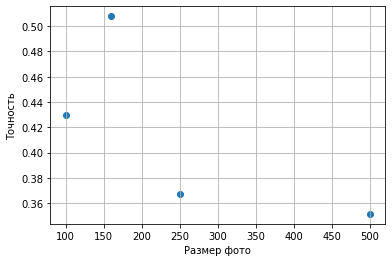

In [127]:
plt.scatter([100, 160, 250, 500], [acc_100, acc_160, acc_250, acc_500])
plt.grid(True)
plt.xlabel('Размер фото')
plt.ylabel('Точность')
plt.show()

В общем на самом деле очень классное задание, оно полезнее всех предыдущих и заставляет прям очень хорошо попытаться понять, что к чему, гораздо глубже. Мне было как-то проще на сифар10 все делать, а тут прям сложно, я потратил вообще на это задание очень много времени, больше чем на любые другие из предыдущих лекций. Но признаюсь честно, именно после этого задания я понял, что не совсем понял, как именно считать все числа в conv2d, maxpool2d и Linear. Т.е. по отдельности, что где и за что отвечает понятно, но как именно связано между собой не совсем понятно, пересматривал лекцию нескоько раз... В общем было бы хорошо услышать еще раз объяснение.

Касаемо вывода к данному заданию. Я думаю, чем больше размер фотографии - тем большую точность можно достичь, но при этом надо менять и структуру сети. При постоянной структуре сверточной части, по-видимому, есть некий оптимум, который можно увидеть на графике. Я не стал использовать много эпох, но проверял, если взять 100 эпох, то accuracy будет больше, до 80-90 процентов на тесте(в зависимости от размера фото). Но это очень долго я решил ограничится 20 эпохами, также мне кажется лучше использовать лернинг рейт 0.001, а не тот который мы фиксировали в начале этого урока. Вероятно у меня не самая лучшая сеть полчилась, но как мне кажется в полне адекватная картина была получена. Значение первой точки можно объяснить по-разному, однако мне кажется, низкое значение accuracy  в этой точке связано уже относительно маленьким размером фотографии, а именно нессовсем оптимальным способом изменения размера фотографии с помощью maxpool2d, вероятно было бы лучше просто обрезать фотографию или сделать нечто подобное, а при условии использования поиска максимума по такому большому квадрату могло произойти, что угодно, т.е. шанс на ошибку становится с какого-то определенного уровня больше.